In [ ]:
# pip install pmdarima statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
store1 = pd.read_csv('store1_timeseries.csv',
                      parse_dates=['Date'], index_col='Date')

In [ ]:
split_date = '2015-06-15'
s1_train = store1[store1.index < split_date]
s1_test  = store1[store1.index >= split_date]

In [ ]:
print(f"Store 1 Train: {s1_train.shape} | {s1_train.index.min()} to {s1_train.index.max()}")
print(f"Store 1 Test : {s1_test.shape}  | {s1_test.index.min()} to {s1_test.index.max()}")
print(f"\nSales stats:\n{store1['Sales'].describe()}")

Store 1 Train: (740, 4) | 2013-01-02 00:00:00 to 2015-06-13 00:00:00
Store 1 Test : (41, 4)  | 2015-06-15 00:00:00 to 2015-07-31 00:00:00

Sales stats:
count     781.000000
mean     4759.096031
std      1012.106393
min      2362.000000
25%      4000.000000
50%      4647.000000
75%      5348.000000
max      9528.000000
Name: Sales, dtype: float64


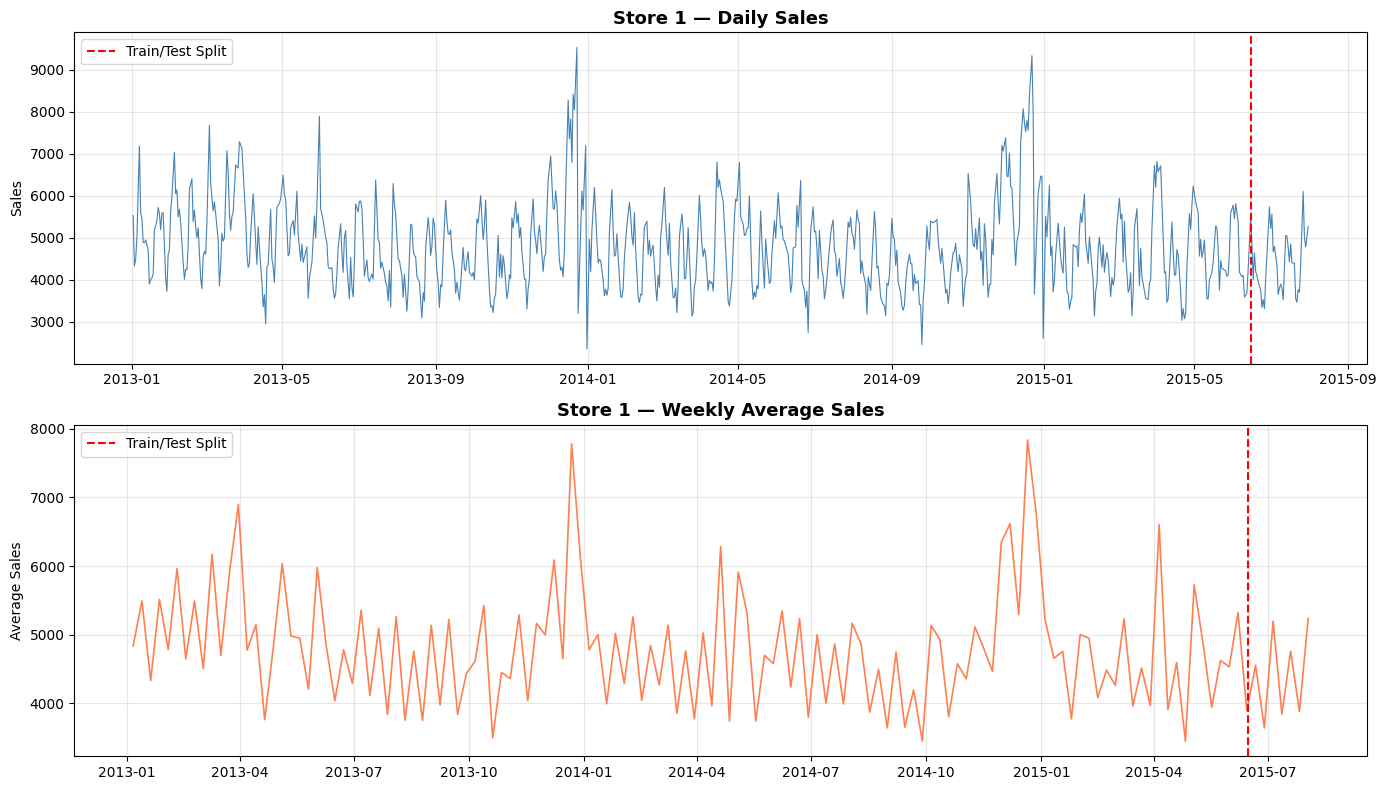

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(store1.index, store1['Sales'],
             color='steelblue', linewidth=0.8)
axes[0].axvline(pd.Timestamp(split_date), color='red',
                linestyle='--', label='Train/Test Split')
axes[0].set_title('Store 1 — Daily Sales', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

weekly = store1['Sales'].resample('W').mean()
axes[1].plot(weekly.index, weekly.values,
             color='coral', linewidth=1.2)
axes[1].axvline(pd.Timestamp(split_date), color='red',
                linestyle='--', label='Train/Test Split')
axes[1].set_title('Store 1 — Weekly Average Sales', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Sales')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_store1_series.png', dpi=150, bbox_inches='tight')
plt.show()

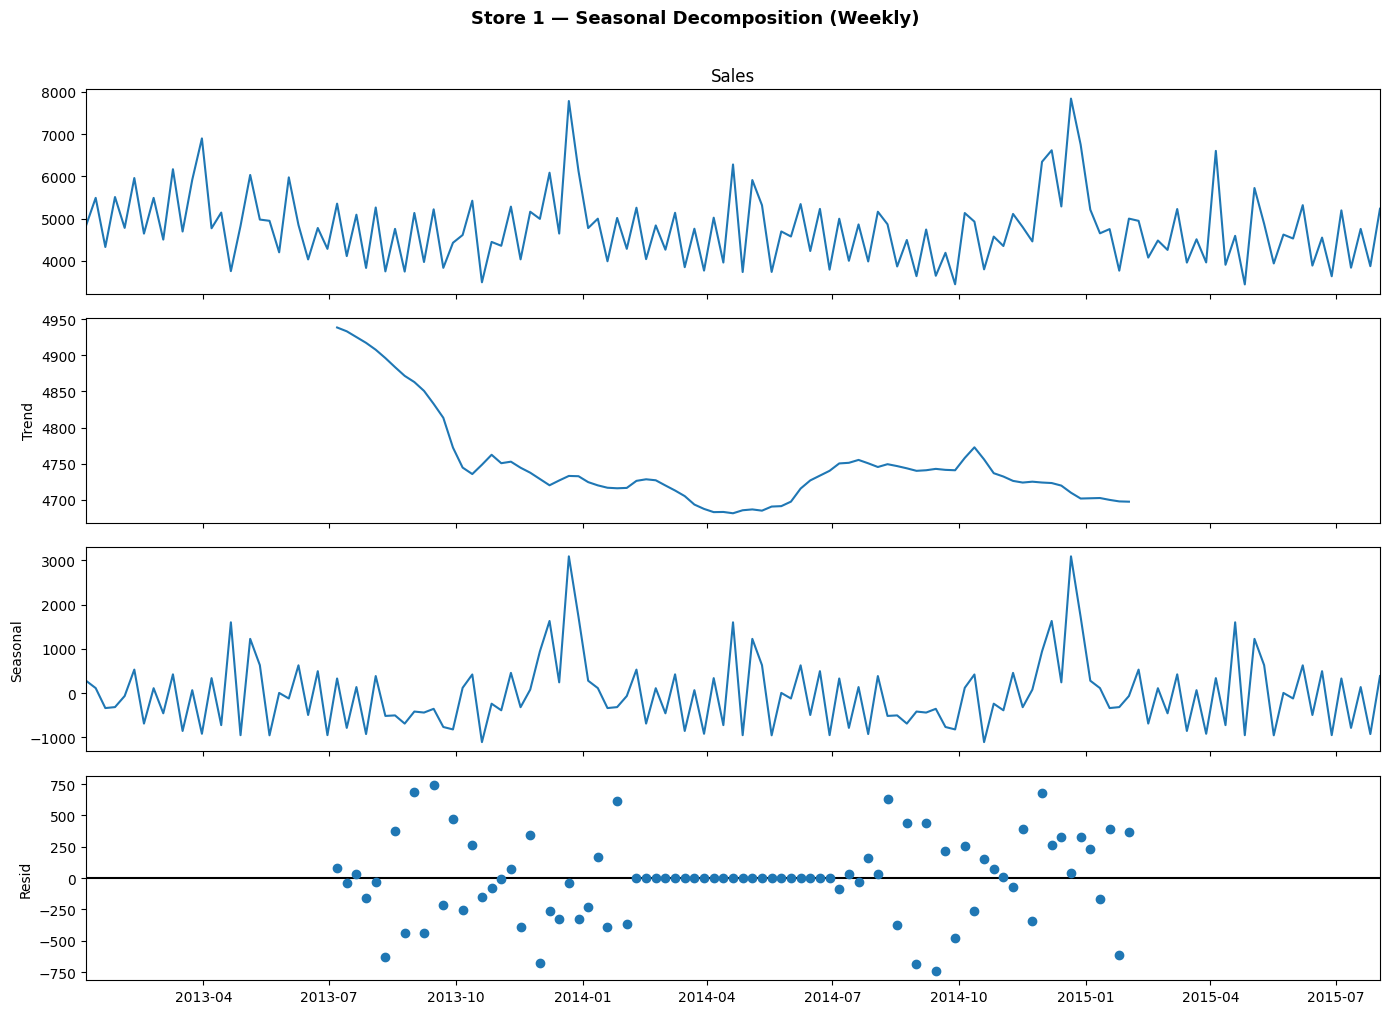

In [ ]:
decomp = seasonal_decompose(weekly, model='additive', period=52)
fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Store 1 — Seasonal Decomposition (Weekly)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def adf_test(series, name = 'Series'):
  result = adfuller(series.dropna())
  print(f"\nADF Test — {name}")
  print(f"  ADF Statistic : {result[0]:.4f}")
  print(f"  p-value       : {result[1]:.4f}")
  print(f"  Stationary    : {'YES' if result[1] < 0.05 else 'NO — differencing needed'}")

adf_test(s1_train['Sales'], 'Raw Sales')

adf_test(s1_train['Sales'].diff().dropna(), '1st Order Difference Sales')


ADF Test — Raw Sales
  ADF Statistic : -5.2950
  p-value       : 0.0000
  Stationary    : YES

ADF Test — 1st Order Difference Sales
  ADF Statistic : -10.0924
  p-value       : 0.0000
  Stationary    : YES


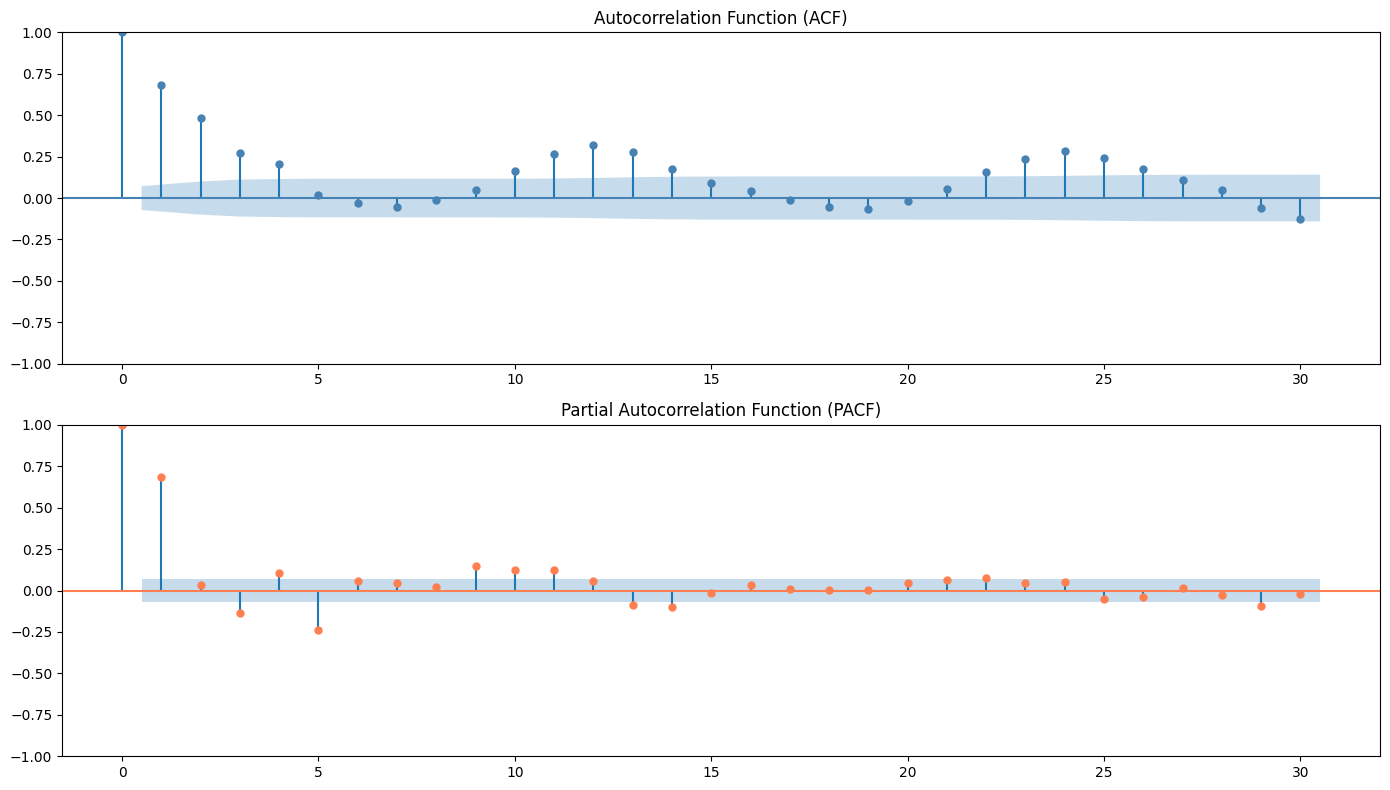

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(s1_train['Sales'].dropna(), lags=30, ax=axes[0],
         color='steelblue', title='Autocorrelation Function (ACF)')
plot_pacf(s1_train['Sales'].dropna(), lags=30, ax=axes[1],
          color='coral', title='Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.savefig('03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
weekly_train = s1_train['Sales'].resample('W').mean()
weekly_test = s1_test['Sales'].resample('W').mean()

print('Running auto_arima')

auto_model = auto_arima(weekly_train,
                        seasonal = True,
                        m = 52,
                        d = None,
                        D = None,
                        Stepwise = True,
                        information_criterion = 'aic',
                        trace = True,
                        error_action = 'ignore',
                        suppress_warnings = True,
                        max_p = 3, max_q=3,
                        max_P = 2, max_Q = 2)

print(f"\nBest model: {auto_model.order} x {auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.2f}")


Running auto_arima
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=2062.973, Time=21.10 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=2092.410, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=2090.323, Time=2.55 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=inf, Time=2.21 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=2538.911, Time=0.02 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=2063.486, Time=5.45 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=2066.649, Time=8.98 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=inf, Time=43.18 sec
 ARIMA(2,0,2)(1,0,2)[52] intercept   : AIC=inf, Time=41.44 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=2080.132, Time=0.13 sec
 ARIMA(2,0,2)(0,0,2)[52] intercept   : AIC=inf, Time=37.12 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=2068.738, Time=33.83 sec
 ARIMA(2,0,2)(2,0,2)[52] intercept   : AIC=inf, Time=50.52 sec
 ARIMA(1,0,2)(1,0,1)[52] intercept   : AIC=2061.863, Time=9.61 sec
 ARIMA(1,0,2)(0,0,1

In [ ]:
p, d, q = auto_model.order
P, D, Q, s = auto_model.seasonal_order

In [ ]:
sarima_model = SARIMAX(
    weekly_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                  128
Model:             SARIMAX(1, 0, 2)x(1, 0, [], 52)   Log Likelihood                -602.089
Date:                             Sat, 06 Jun 2026   AIC                           1214.178
Time:                                     00:41:38   BIC                           1225.766
Sample:                                 01-06-2013   HQIC                          1218.805
                                      - 06-14-2015                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9941      0.012     84.479      0.000       0.971       1.017
ma.L1         -0.9054      

In [ ]:
n_periods = len(weekly_test)
forecast_result = sarima_fit.get_forecast(steps=n_periods)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

print(f"\nForecast periods: {n_periods} weeks")


Forecast periods: 7 weeks


In [ ]:
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

actuals = weekly_test.values
preds   = forecast_mean.values[:len(actuals)]

mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mape_val = mape(actuals, preds)

In [ ]:
print("=" * 40)
print("SARIMA — Store 1 Performance (Weekly)")
print("=" * 40)
print(f"  MAE  : {mae:,.2f}")
print(f"  RMSE : {rmse:,.2f}")
print(f"  MAPE : {mape_val:.2f}%")
print("=" * 40)

SARIMA — Store 1 Performance (Weekly)
  MAE  : 378.72
  RMSE : 403.39
  MAPE : 8.49%


In [ ]:
sarima_metrics = {'Model': 'SARIMA', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val}

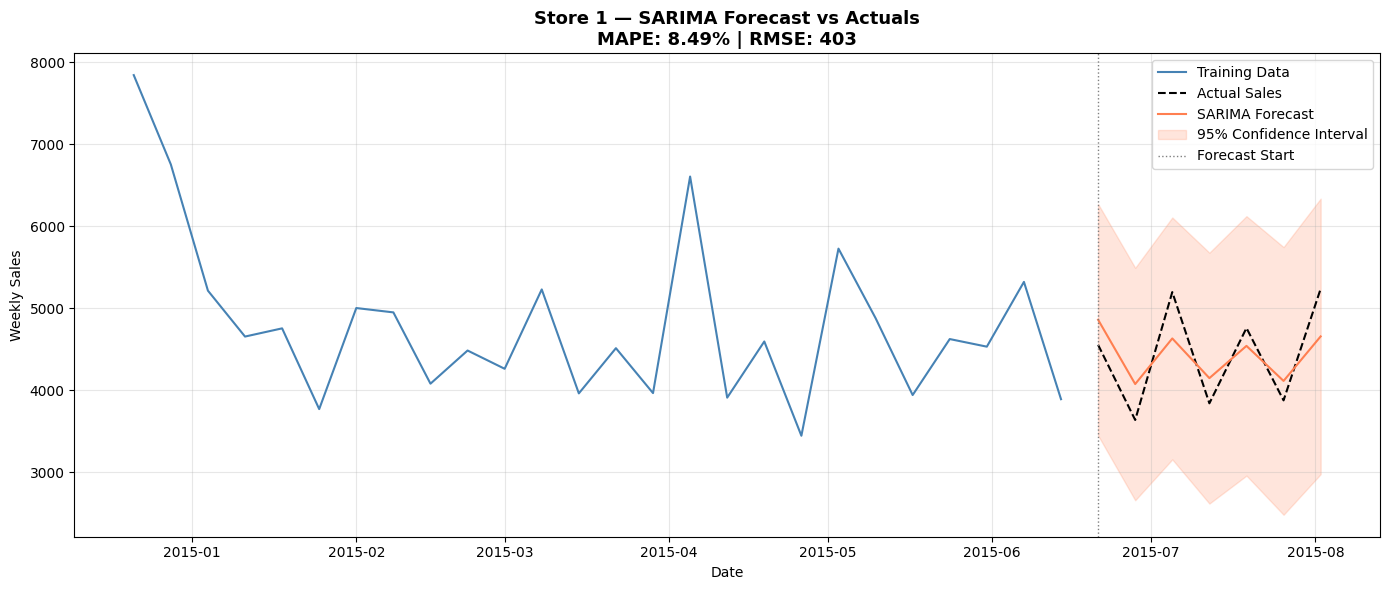

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(weekly_train[-26:].index, weekly_train[-26:].values,
        color='steelblue', linewidth=1.5, label='Training Data')


ax.plot(weekly_test.index, weekly_test.values,
        color='black', linewidth=1.5, linestyle='--', label='Actual Sales')

ax.plot(weekly_test.index[:len(preds)], preds,
        color='coral', linewidth=1.5, label='SARIMA Forecast')

ax.fill_between(weekly_test.index[:len(preds)],
                forecast_ci.iloc[:len(preds), 0],
                forecast_ci.iloc[:len(preds), 1],
                color='coral', alpha=0.2, label='95% Confidence Interval')

ax.axvline(weekly_test.index[0], color='gray',
           linestyle=':', linewidth=1, label='Forecast Start')
ax.set_title(f'Store 1 — SARIMA Forecast vs Actuals\nMAPE: {mape_val:.2f}% | RMSE: {rmse:,.0f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import json

with open('sarima_metrics.json', 'w') as f:
    json.dump(sarima_metrics, f)

print("SARIMA metrics saved")
print(sarima_metrics)

SARIMA metrics saved
{'Model': 'SARIMA', 'MAE': 378.7183677236923, 'RMSE': np.float64(403.39301798540856), 'MAPE': np.float64(8.486603225714543)}
